/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


Latitude: 50.7404
Longitude: 5.8868
Elevation (m): 179.0


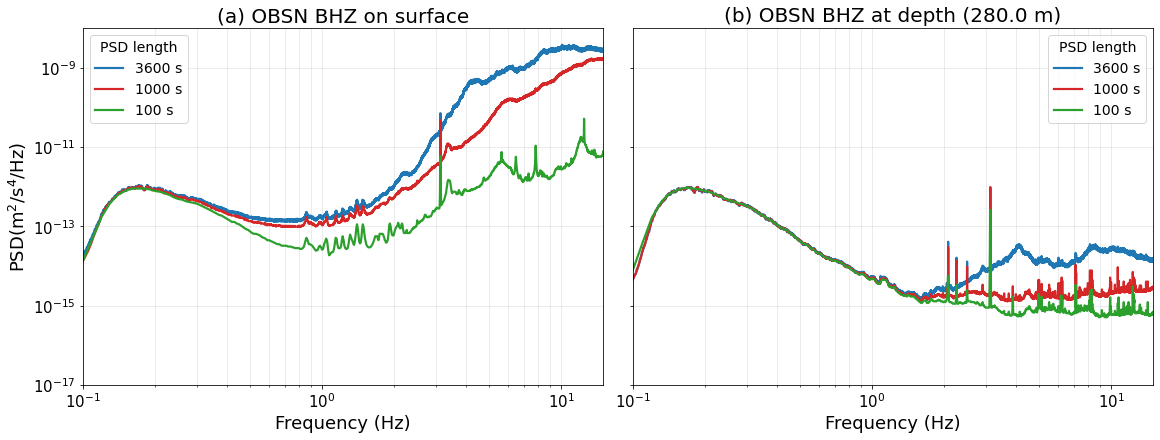

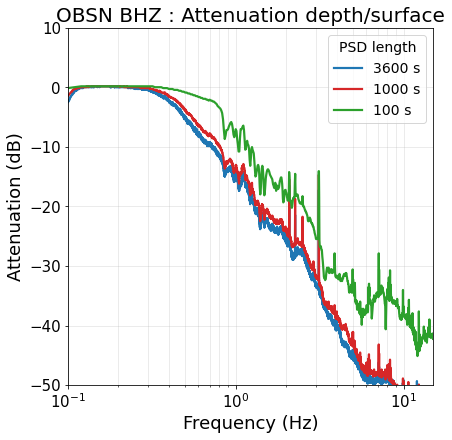

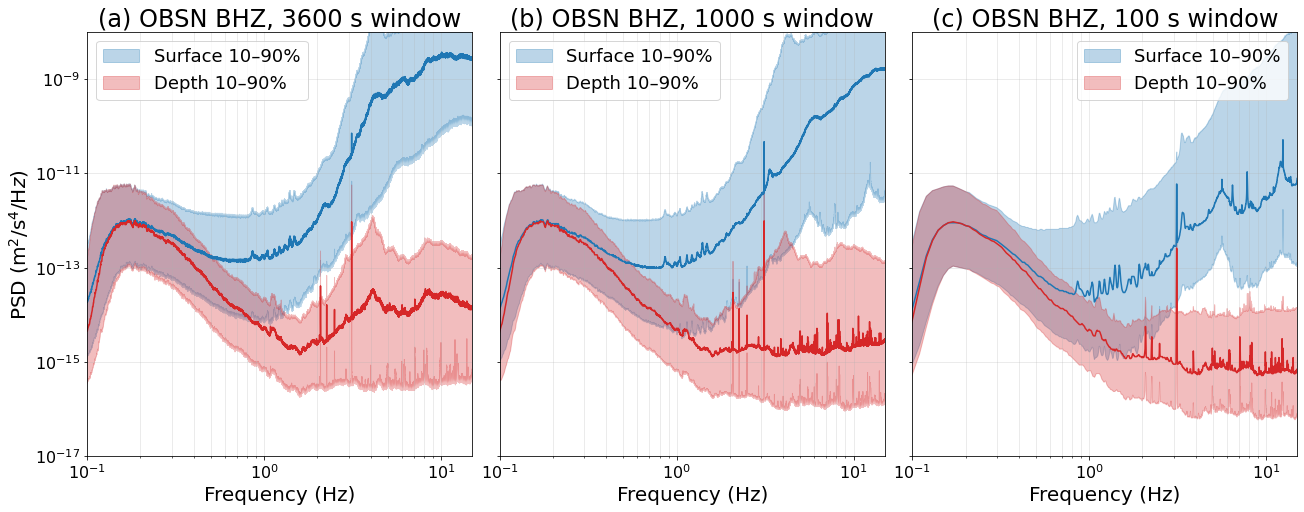

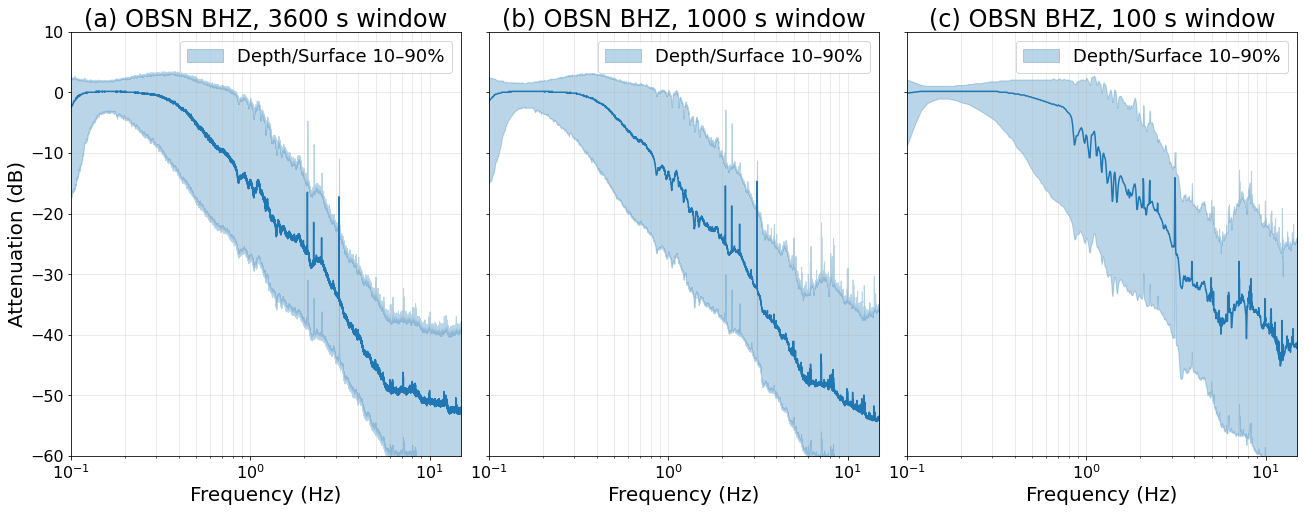

In [2]:
# script for plotting the outpts of studyPSDAttnWinLen.py script
import os
import re
import math
import pickle
import datetime
import numpy as np
import scipy.signal as sp
import matplotlib.pyplot as plt

from obspy import read_inventory, UTCDateTime
from obspy.clients.filesystem.sds import Client
from modules import psdLenMod

# run this for the plots when you have computed the histograms
stnName = 'OBSN'
compName = 'BHZ'

saved_files = '/data/gravwav/koley/PSDHistBoreholes/PSDLengthAnalysis/OBSN_BHZ_pair_hist.pkl'
# extract the station location and depth
inventory_files = {
    stnName: '/dcache/etseis/et/EMR/Stations/Stations/NL.' + stnName + '.xml',
}
inventories = {sta: read_inventory(path) for sta, path in inventory_files.items()}
net = inventories[stnName].select(network="NL", station=stnName, location="01", channel=compName)[0]
sta01 = net.stations[0]
cha01 = sta01.channels[0]
cha01Depth = cha01.depth
print("Latitude:", sta01.latitude)
print("Longitude:", sta01.longitude)
print("Elevation (m):", sta01.elevation)
psdLenMod.plot_pair_results(saved_files,cha01Depth,title_prefix=stnName + ' '+ compName)
    
psdLenMod.plot_prct_bands(saved_files, lengths_to_plot=(3600, 1000, 100), qty_key= 'PSD', title_prefix=stnName + ' '+ compName)
psdLenMod.plot_prct_bands(saved_files, lengths_to_plot=(3600, 1000, 100), qty_key= 'Attn', title_prefix=stnName + ' '+ compName)
